In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
target_col = "species"
feature_cols = [c for c in df.columns if c != target_col]

In [5]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

**Cleaning up the values of NaN**

In [7]:
before_rows = df.shape[0] # total number of rows before cleaning
df = df.dropna()
after_rows = df.shape[0] # total number of rows after cleaning
print(f"Total number of rows before cleaning: {before_rows}\nTotal number of rows after cleaning: {after_rows}")

Total number of rows before cleaning: 344
Total number of rows after cleaning: 334


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            334 non-null    object 
 1   island             334 non-null    object 
 2   culmen_length_mm   334 non-null    float64
 3   culmen_depth_mm    334 non-null    float64
 4   flipper_length_mm  334 non-null    float64
 5   body_mass_g        334 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.9+ KB


In [9]:
# Basic statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", numeric_cols)

Numerical columns: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']


In [10]:
# Infos about numerical columns
print(df[numeric_cols].describe().T)

                   count         mean         std     min     25%     50%  \
culmen_length_mm   334.0    43.994311    5.460521    32.1    39.5    44.5   
culmen_depth_mm    334.0    17.160479    1.967909    13.1    15.6    17.3   
flipper_length_mm  334.0   201.014970   14.022175   172.0   190.0   197.0   
body_mass_g        334.0  4209.056886  804.836129  2700.0  3550.0  4050.0   

                        75%     max  
culmen_length_mm     48.575    59.6  
culmen_depth_mm      18.700    21.5  
flipper_length_mm   213.000   231.0  
body_mass_g        4793.750  6300.0  


In [11]:
df["sex"].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [12]:
# Removes erroneous values like "." and eliminates case sensitivity
df.loc [:,"sex"] = df["sex"].astype(str).str.strip().str.upper()
df = df[df["sex"].isin(["MALE", "FEMALE"])]
df["sex"].unique()

array(['MALE', 'FEMALE'], dtype=object)

In [13]:
df["island"].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [14]:
df["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [15]:
categ_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Categorical columns:", categ_cols)

Categorical columns: ['species', 'island', 'sex']


In [16]:
for c in categ_cols:
    print(f"Value counts for '{c}':\n")
    print(df[c].value_counts(dropna=False),"\n")

Value counts for 'species':

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64 

Value counts for 'island':

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64 

Value counts for 'sex':

sex
MALE      168
FEMALE    165
Name: count, dtype: int64 



In [17]:
group_means = df.groupby(target_col)[numeric_cols].mean().round(2)
print("Average numerical characteristics by type:\n")
print(group_means)

Average numerical characteristics by type:

           culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
species                                                                     
Adelie                38.82            18.35             190.10      3706.16
Chinstrap             48.83            18.42             195.82      3733.09
Gentoo                47.57            15.00             217.24      5092.44


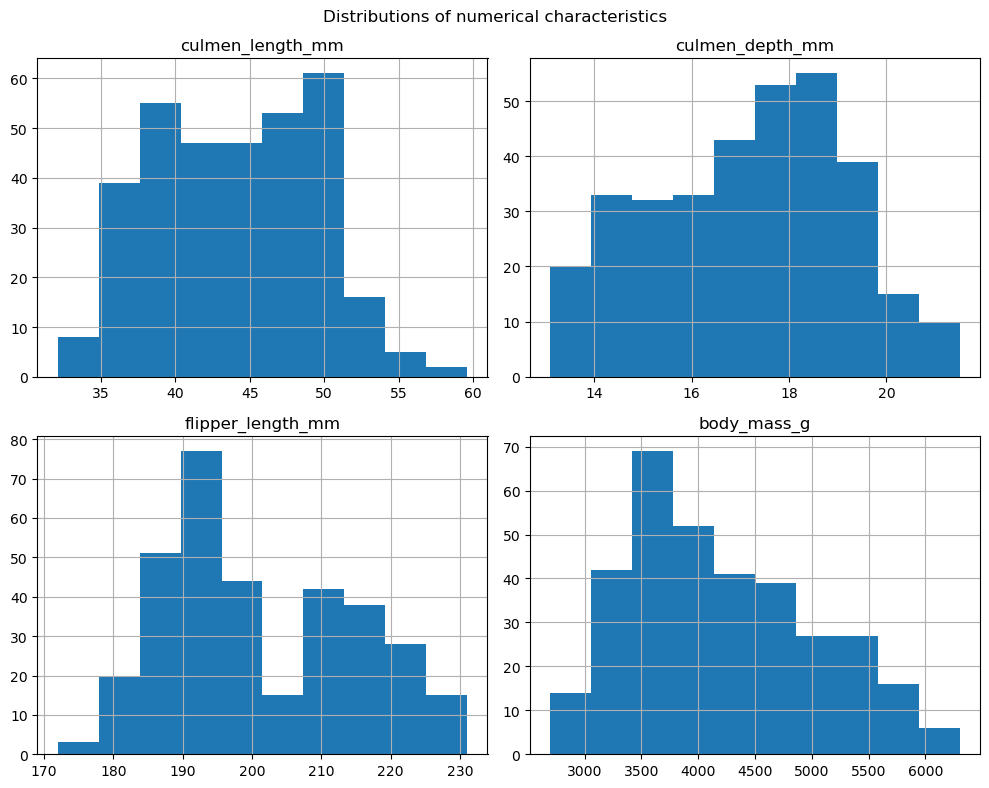

In [35]:
# Simple visiulation
ax = df[numeric_cols].hist(figsize=(10,8))
plt.suptitle("Distributions of numerical characteristics")
plt.tight_layout()
plt.show()

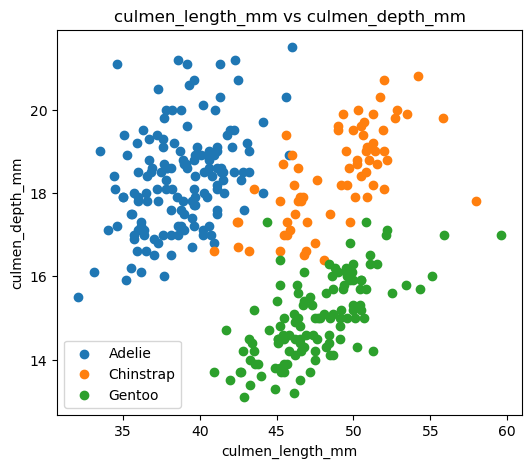

In [43]:
plt.figure(figsize=(6,5))
for sp in df["species"].unique():
    sub = df[df["species"] == sp]
    plt.scatter(sub["culmen_length_mm"], sub["culmen_depth_mm"], label=sp)
plt.title("culmen_length_mm vs culmen_depth_mm")
plt.xlabel("culmen_length_mm")
plt.ylabel("culmen_depth_mm")
plt.legend()
plt.show()

In [45]:
y = df[target_col] # outcome
X = df.drop(columns=[target_col]) # features

In [47]:
feature_cols = ["island", "sex"]

In [51]:
# One Hot Encoder + ColumnTransformer 
preprocess = ColumnTransformer(
    transformers=[
        ("num", "pass_through", numeric_cols), # pass the numbers exactly
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cols)
    ]
)

In [55]:
# Pipeline + GridSearchCV

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "rf__n_estimators": [100, 300, 500],    # Numbers of tree
    "rf__max_depth": [None, 5, 10, 15],     # Tree dept limit
    "rf__max_features": ["sqrt", "log2"]    # Numbers of features to test at each node
}

In [57]:
grid = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    cv = 5,                   # 5-Fold Cross-Validation
    n_jobs = -1,              # Use all cores in the computer
    scoring = "accuracy"
)